# Week 1.1: Probability & Neural Networks for Digital Twins

## Learning Objectives
- Understand how AI makes predictions using probability
- Learn the basics of neural networks
- Apply these concepts to building a digital twin

## Digital Twin Context
A **digital twin** is a virtual representation of a physical entity (person, object, system). In this series, we'll build a digital twin that can:
- Predict behaviors and preferences
- Understand and respond to language
- Learn from interactions

## Key Insight
> "AI isn't thinking; it's predicting the next number."

This applies to everything from weather prediction to language generation!

---
## Part 1: Probability Foundations

Let's start with the basics: How does AI make predictions?

In [13]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


### 1.1 Simple Prediction: Next Number

Let's simulate a digital twin predicting your next action based on historical data.

Activity Probabilities:
  Sleep: 20.00%
  Work: 40.00%
  Exercise: 13.33%
  Social: 13.33%
  Leisure: 13.33%


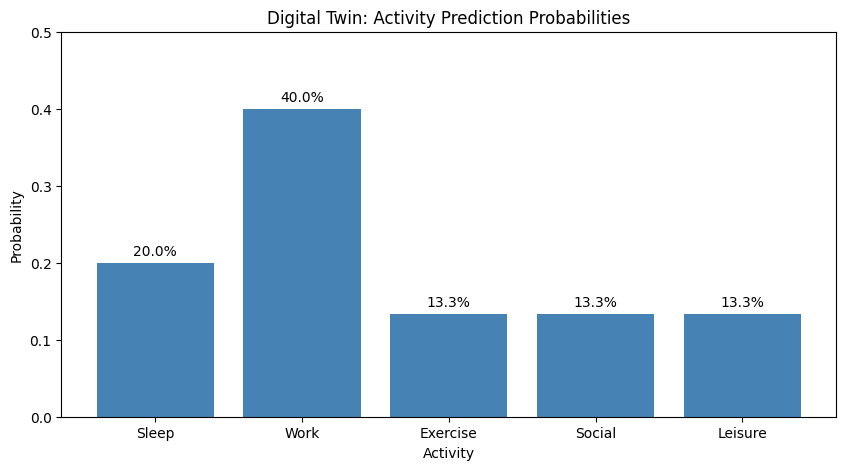

In [14]:
from collections import Counter
import matplotlib.pyplot as plt

# Example: Predicting daily activities (represented as numbers)
# 0=Sleep, 1=Work, 2=Exercise, 3=Social, 4=Leisure

historical_activities = [0, 1, 2, 1, 3, 1, 4, 0, 1, 2, 1, 3, 1, 4, 0]

def calculate_probabilities(sequence):
    """
    Calculate probability distribution from a sequence.

    Args:
        sequence: List of integers representing activities

    Returns:
        dict: Probability of each activity
    """
    counts = Counter(sequence)
    total = len(sequence)
    probabilities = {activity: count/total for activity, count in counts.items()}
    return probabilities

# Calculate probabilities
probs = calculate_probabilities(historical_activities)

# Display results
activity_names = {0: 'Sleep', 1: 'Work', 2: 'Exercise', 3: 'Social', 4: 'Leisure'}
print("Activity Probabilities:")
for activity, prob in sorted(probs.items()):
    print(f"  {activity_names[activity]}: {prob:.2%}")

# Visualize
plt.figure(figsize=(10, 5))
activities = [activity_names[k] for k in sorted(probs.keys())]
probabilities = [probs[k] for k in sorted(probs.keys())]
plt.bar(activities, probabilities, color='steelblue')
plt.title('Digital Twin: Activity Prediction Probabilities')
plt.ylabel('Probability')
plt.xlabel('Activity')
plt.ylim(0, 0.5)
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.show()

### 🎯 Exercise 1.1 (Easy): Understanding Probabilities

**Task**: Modify the historical activities to represent your own daily routine for 2 weeks (14 days).

**Questions**:
1. Which activity has the highest probability?
2. What does this tell you about the pattern in your data?
3. How would adding more data points affect the predictions?

 Sleep: 21.43%
 Work: 50.00%
 Exercise: 7.14%
 Social: 7.14%
 Leisure: 14.29%


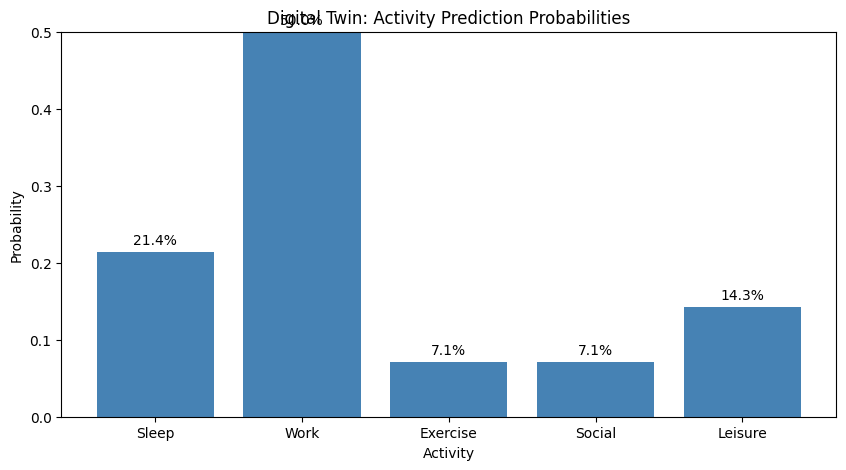

In [17]:
# YOUR CODE HERE
# Create your own sequence of activities (14 values)
# 0=Sleep, 1=Work, 2=Exercise, 3=Social, 4=Leisure
my_activities = [0, 1, 1, 1, 4, 0, 2, 1, 1, 3, 4, 0, 1, 1]  # Replace with your pattern

# Calculate and visualize
my_probs = calculate_probabilities(my_activities)

#display results
activity_names = {0 : 'Sleep', 1 : 'Work', 2 : 'Exercise', 3 : 'Social', 4 : 'Leisure'}
for activity, prob in sorted(my_probs.items()):
  print(f" {activity_names[activity]}: {prob:.2%}")

#visualize
plt.figure(figsize=(10, 5))
activities = [activity_names[k] for k in sorted(my_probs.keys())]
probabilities = [my_probs[k] for k in sorted(my_probs.keys())]
plt.bar(activities, probabilities, color='steelblue')
plt.title('Digital Twin: Activity Prediction Probabilities')
plt.ylabel('Probability')
plt.xlabel('Activity')
plt.ylim(0, 0.5)
for i, v in enumerate(probabilities):
  plt.text(i, v + 0.01, f'{v:.1%}', ha='center')
plt.show()

# YOUR ANALYSIS HERE (write answers as comments)
# 1. Highest probability activity: #work
# 2. Pattern insight: #work occurred more in my activity sequence
# 3. Impact of more data: #more data improves the accuracy and reliability of predictions

### 1.2 Conditional Probability: Context Matters

What if predictions depend on previous activities? This is where context comes in!

In [18]:
def calculate_conditional_probabilities(sequence):
    """
    Calculate P(next | current) - probability of next activity given current.

    Args:
        sequence: List of activities

    Returns:
        dict: Nested dictionary of conditional probabilities
    """
    transitions = {}

    for i in range(len(sequence) - 1):
        current = sequence[i]
        next_activity = sequence[i + 1]

        if current not in transitions:
            transitions[current] = []
        transitions[current].append(next_activity)

    # Convert to probabilities
    conditional_probs = {}
    for current, next_list in transitions.items():
        counts = Counter(next_list)
        total = len(next_list)
        conditional_probs[current] = {activity: count/total for activity, count in counts.items()}

    return conditional_probs

# Calculate conditional probabilities
cond_probs = calculate_conditional_probabilities(historical_activities)

# Display
print("Conditional Probabilities: P(Next | Current)\n")
for current, next_probs in cond_probs.items():
    print(f"After {activity_names[current]}:")
    for next_activity, prob in sorted(next_probs.items()):
        print(f"  → {activity_names[next_activity]}: {prob:.2%}")
    print()

Conditional Probabilities: P(Next | Current)

After Sleep:
  → Work: 100.00%

After Work:
  → Exercise: 33.33%
  → Social: 33.33%
  → Leisure: 33.33%

After Exercise:
  → Work: 100.00%

After Social:
  → Work: 100.00%

After Leisure:
  → Sleep: 100.00%



### 🎯 Exercise 1.2 (Intermediate): Markov Chain Prediction

**Task**: Build a simple predictor that uses conditional probabilities to predict the next activity.

**Challenge**: What happens after "Work"? Which activity is most likely?

In [22]:
def predict_next_activity(current_activity, conditional_probs):
    """
    Predict the most likely next activity.

    Args:
        current_activity: Current activity code
        conditional_probs: Dictionary of conditional probabilities

    Returns:
        int: Most likely next activity
    """
    # YOUR CODE HERE
    # Hint: Find the activity with maximum probability given current_activity
    if current_activity not in conditional_probs:
        return None

    next_probs = conditional_probs[current_activity]
    # Complete this function
    predicted_activity = max(next_probs, key=next_probs.get)

    return predicted_activity

# Test your function
current = 1  # Work
predicted = predict_next_activity(current, cond_probs)
print(f"After {activity_names[current]}, most likely next: {activity_names.get(predicted, 'Unknown')}")

# BONUS: Predict a sequence of 5 activities starting from "Work"

After Work, most likely next: Exercise


---
## Part 2: Neural Networks Basics

Now let's see how neural networks learn to make predictions!

### 2.1 The Perceptron: Building Block of Neural Networks

A perceptron is the simplest neural network - it takes inputs, applies weights, and produces an output.

In [ ]:
import numpy as np

def sigmoid(x):
    """Sigmoid activation function."""
    return 1 / (1 + np.exp(-x))

def perceptron(inputs, weights, bias):
    """
    Simple perceptron implementation.

    Args:
        inputs: Array of input values
        weights: Array of weights
        bias: Bias term

    Returns:
        float: Output after activation
    """
    # Calculate weighted sum
    weighted_sum = np.dot(inputs, weights) + bias
    # Apply activation function
    output = sigmoid(weighted_sum)
    return output

# Example: Predicting if someone will exercise based on features
# Features: [hours_of_sleep, free_time_hours, energy_level (0-1)]
person_features = np.array([7, 2, 0.8])  # 7 hours sleep, 2 hours free time, high energy

# Initialize random weights
weights = np.array([0.3, 0.5, 0.7])
bias = -0.5

prediction = perceptron(person_features, weights, bias)
print(f"Probability of exercising: {prediction:.2%}")
print(f"Prediction: {'Will exercise' if prediction > 0.5 else 'Will not exercise'}")

Probability of exercising: 95.93%
Prediction: Will exercise


### 🎯 Exercise 2.1 (Easy): Feature Engineering

**Task**: Modify the features and observe how the prediction changes.

**Questions**:
1. What happens when sleep hours decrease to 4?
2. What if free time increases to 4 hours?
3. Which feature seems to have the most impact based on the weights?

In [ ]:
# YOUR CODE HERE
# Test different feature combinations

test_cases = [
    np.array([4, 2, 0.8]),  # Low sleep
    np.array([7, 4, 0.8]),  # More free time
    np.array([7, 2, 0.3]),  # Low energy
]

# Test each case and analyze results


### 2.2 Training a Simple Neural Network





Let's see how a network learns by adjusting weights!

In [ ]:
class SimpleNeuralNetwork:
    """A simple neural network with one hidden layer."""

    def __init__(self, input_size, hidden_size, output_size):
        # Initialize weights randomly
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

        # Store training history
        self.loss_history = []

    def forward(self, X):
        """Forward pass through the network."""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, learning_rate=0.1):
        """Backward pass - update weights."""
        m = X.shape[0]

        # Calculate gradients
        dz2 = output - y
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.a1 * (1 - self.a1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

    def train(self, X, y, epochs=1000, learning_rate=0.1):
        """Train the network."""
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Calculate loss
            loss = np.mean((output - y) ** 2)
            self.loss_history.append(loss)

            # Backward pass
            self.backward(X, y, output, learning_rate)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        """Make predictions."""
        return self.forward(X)

# Create training data for digital twin
# Features: [day_of_week (0-6), time_of_day (0-23), weather (0-1), mood (0-1)]
# Target: [probability of social activity]

np.random.seed(42)
X_train = np.random.rand(100, 4)
# Simulate pattern: social activity more likely on weekends (day > 5) and good weather
y_train = ((X_train[:, 0] > 0.7) & (X_train[:, 2] > 0.5)).astype(float).reshape(-1, 1)
y_train += np.random.rand(100, 1) * 0.2  # Add noise
y_train = np.clip(y_train, 0, 1)

# Create and train network
nn = SimpleNeuralNetwork(input_size=4, hidden_size=8, output_size=1)
print("Training neural network...\n")
nn.train(X_train, y_train, epochs=500, learning_rate=0.5)

In [ ]:
# Visualize training progress
plt.figure(figsize=(10, 5))
plt.plot(nn.loss_history)
plt.title('Neural Network Training: Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal loss: {nn.loss_history[-1]:.4f}")

### 🎯 Exercise 2.2 (Intermediate): Digital Twin Prediction

**Task**: Test the trained network on new scenarios and interpret results.

**Scenarios to test**:
1. Weekend evening (day=6, time=18, weather=0.8, mood=0.9)
2. Weekday morning (day=2, time=8, weather=0.3, mood=0.5)
3. Weekend with bad weather (day=5, time=14, weather=0.2, mood=0.6)

In [ ]:
# YOUR CODE HERE
# Normalize inputs (scale to 0-1 range)
def normalize_input(day, time, weather, mood):
    return np.array([[day/7, time/24, weather, mood]])

# Test scenarios
scenarios = [
    ("Weekend evening, good weather", 6, 18, 0.8, 0.9),
    ("Weekday morning, poor weather", 2, 8, 0.3, 0.5),
    ("Weekend afternoon, bad weather", 5, 14, 0.2, 0.6),
]

# Make predictions and analyze
for name, day, time, weather, mood in scenarios:
    X_test = normalize_input(day, time, weather, mood)
    prediction = nn.predict(X_test)
    print(f"{name}")
    print(f"  Social activity probability: {prediction[0][0]:.2%}\n")

### 🎯 Exercise 2.3 (Advanced): Improve the Digital Twin

**Task**: Enhance the neural network to make better predictions.

**Challenges**:
1. Add more training data with realistic patterns
2. Experiment with different network architectures (hidden layer size)
3. Try different learning rates
4. Add a second hidden layer
5. Create a visualization showing prediction accuracy

In [ ]:
# YOUR CODE HERE
# Challenge: Create a better training dataset

def generate_realistic_data(n_samples=500):
    """
    Generate more realistic training data for digital twin.

    Pattern rules:
    - Social activity higher on weekends
    - Time of day matters (evening > morning)
    - Good weather increases probability
    - Good mood increases probability
    """
    # YOUR CODE HERE
    pass

# Test different architectures
architectures = [
    (4, 4, 1),   # Small
    (4, 8, 1),   # Medium (original)
    (4, 16, 1),  # Large
]

# Compare performance


---
## Part 3: Connecting to LLMs

How does this relate to Large Language Models?

### 3.1 From Activities to Words

LLMs work exactly like our activity predictor, but with words!

In [ ]:
# Simple word prediction example
text_sequence = "I love coding in Python because it is"
words = text_sequence.split()

# Simulate word prediction
word_vocab = ['fun', 'easy', 'powerful', 'versatile', 'simple', 'clear', 'elegant']
word_probs = np.random.rand(len(word_vocab))
word_probs = word_probs / word_probs.sum()  # Normalize to probabilities

# Create probability distribution
word_dist = dict(zip(word_vocab, word_probs))
word_dist = dict(sorted(word_dist.items(), key=lambda x: x[1], reverse=True))

print("Given text:", text_sequence)
print("\nPredicted next word probabilities:")
for word, prob in word_dist.items():
    print(f"  {word}: {prob:.2%}")

# Visualize
plt.figure(figsize=(12, 5))
plt.bar(word_dist.keys(), word_dist.values(), color='coral')
plt.title('LLM Word Prediction: P(next_word | context)')
plt.ylabel('Probability')
plt.xlabel('Candidate Words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🎯 Exercise 3.1 (Conceptual): Understanding LLMs

**Questions**:
1. How is predicting the next word similar to predicting the next activity?
2. What role does probability play in both cases?
3. Why might an LLM sometimes generate unexpected words?
4. How does context (previous words) help make better predictions?

Write your answers in the cell below:

**Your Answers:**

1. Similarity between word and activity prediction:
   -

2. Role of probability:
   -

3. Unexpected generations:
   -

4. Importance of context:
   -

---
## Summary & Key Takeaways

### What We Learned:
1. **Probability**: AI predicts by calculating probabilities based on historical patterns
2. **Conditional Probability**: Context matters - knowing what came before improves predictions
3. **Neural Networks**: Learn patterns by adjusting weights through training
4. **Digital Twin**: Can model behaviors using probabilistic predictions
5. **LLM Connection**: Language models are sophisticated versions of these basic concepts

### Next Steps:
In the next notebook, we'll explore:
- How LLMs represent words (embeddings)
- Transformer architecture
- Attention mechanisms
- Building a simple language model for your digital twin

---
## 🏆 Challenge Project (Advanced)

**Build Your Own Digital Twin Predictor**

Create a system that:
1. Collects data about your daily patterns (sleep, activities, mood, etc.)
2. Trains a neural network to predict your next likely activity
3. Evaluates prediction accuracy
4. Visualizes patterns it learned

**Bonus**: Add temporal features (day of week, time of day) and see how they improve predictions!

In [ ]:
# YOUR CHALLENGE PROJECT CODE HERE
# This is your space to be creative!
